
# **CAPSTONE PROJECT TEAM CC26-PSU136**

**Smart Nutrition Scanner**

# **Import Library**
Pada tahap ini, kita akan mengimpor beberapa pustaka (library) Python yang dibutuhkan.


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **DATA WRANGLING: Smart Nutrition Scanner**

### **1. Gathering Data**
Ini adalah tahap pengumpulan data. Karena data sudah ada di CSV, jadi akan dimuatnya ke dalam DataFrame.

In [48]:
# Membaca file dengan detektor pemisah otomatis agar kolom tidak rusak/kosong
df_nutrition = pd.read_csv('Dataset Nilai Gizi - Sheet1.csv')

print("Cek Data Mentah Sebelum Cleaning")
display(df_nutrition[['Nama_Produk', 'Gula_per_sajian (g)', 'Garam_per_sajian (mg)']].head())

Cek Data Mentah Sebelum Cleaning


,Nama_Produk,Gula_per_sajian (g),Garam_per_sajian (mg)
0,Chiki Puffs (cheese),1,50
1,Tango Waffle Choco Hazelnut,5,55
2,Nutrijell Pudding Susu (Red Velvet),5,35
3,Nutrijell Pudding Susu (Strawberry),70,140
4,Indomie Ayam Bawang,2,1220


## **2. Assessing Data**
Tahap ini bertujuan untuk memeriksa struktur data (mencari data kosong, duplikat, atau tipe data yang salah) sebelum masuk ke tahap cleaning.

In [49]:
# Memeriksa tipe data setiap kolom
print("Pengecekan Tipe Data")
print(df_nutrition.info())

Pengecekan Tipe Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   No.                    325 non-null    int64 
 1   Nama_Produk            325 non-null    object
 2   Kategori               325 non-null    object
 3   Ukuran_per_Sajian      323 non-null    object
 4   Satuan                 324 non-null    object
 5   Gula_per_sajian (g)    325 non-null    int64 
 6   Garam_per_sajian (mg)  325 non-null    int64 
 7   Gambar_Normal          246 non-null    object
 8   Gambar_Rotate 90°      216 non-null    object
dtypes: int64(3), object(6)
memory usage: 23.0+ KB
None


In [50]:
# Memeriksa nilai kosong (Missing Values)
print("Pengecekan Missing Values")
print(df_nutrition.isna().sum())

Pengecekan Missing Values
No.                        0
Nama_Produk                0
Kategori                   0
Ukuran_per_Sajian          2
Satuan                     1
Gula_per_sajian (g)        0
Garam_per_sajian (mg)      0
Gambar_Normal             79
Gambar_Rotate 90°        109
dtype: int64


In [51]:
# Memeriksa data duplikat
# Cek duplikat spesifik berdasarkan Nama Produk saja
duplikat_nama = df_nutrition.duplicated(subset=['Nama_Produk']).sum()
print(f"Jumlah duplikat berdasarkan Nama Produk: {duplikat_nama}")

# Membuat filter untuk mengambil baris yang ada nama gambarnya saja (tidak kosong)
valid_images = df_nutrition[df_nutrition['Gambar_Normal'].notna()]

# Menghitung duplikat hanya pada data yang memiliki nama gambar
real_duplicate_count = valid_images.duplicated(subset=['Gambar_Normal']).sum()
print(f"Jumlah duplikat gambar: {real_duplicate_count}")

Jumlah duplikat berdasarkan Nama Produk: 5
Jumlah duplikat gambar: 3


In [52]:
# Memeriksa statistik deskriptif awal (mencari angka aneh/outliers)
print("Statistik Deskriptif")
print(df_nutrition.describe())

Statistik Deskriptif
              No.  Gula_per_sajian (g)  Garam_per_sajian (mg)
count  325.000000           325.000000             325.000000
mean   163.000000             8.046154             143.104615
std     93.963645             7.545399             274.968789
min      1.000000             0.000000               0.000000
25%     82.000000             2.000000              25.000000
50%    163.000000             6.000000              60.000000
75%    244.000000            12.000000             115.000000
max    325.000000            70.000000            1460.000000


**Insight:**
Kami menemukan bahwa ada kolom yang tidak diperlukan untuk analisis statistik (Gambar Rotate) dan didapatkan nilai kosong sebanyak 79 untuk gambar_normal, 109 gambar_rotate 90°, 2 ukuran_per_sajian, serta 1 untuk satuan.

Selain itu, ditemukan data duplikat pada dataset kami. Terdapat 5 produk yang duplikat (berdasarkan nama_produk), serta terdapat 3 gambar duplikat berdasarkan kolom gambar_normal.


### **3. Cleaning Data**
Setelah diketahui masalahnya di tahap Assessing (ada kolom yang tidak diperlukan, mising values, serta duplikat), sekarang kita bersihkan pada tahap cleaning data berikut.

In [53]:
# Membuat salinan data agar data asli tetap aman
df_clean = df_nutrition.copy()

In [54]:
# Standarisasi merapikan Teks (Menghapus spasi di depan atau belakang teks agar kategori seragam)
df_clean['Nama_Produk'] = df_clean['Nama_Produk'].astype(str).str.strip()
df_clean['Kategori'] = df_clean['Kategori'].astype(str).str.strip()

In [55]:
# Mengubah Ukuran_per_Sajian ke numerik karena tipenya masih 'object'
df_clean['Ukuran_per_Sajian'] = pd.to_numeric(df_clean['Ukuran_per_Sajian'], errors='coerce')
df_clean['Ukuran_per_Sajian'] = df_clean['Ukuran_per_Sajian'].fillna(df_clean['Ukuran_per_Sajian'].median())

In [56]:
# Menangani Tipe Data (memastikan Ukuran_per_Sajian adalah angka atau float)
df_clean['Gula_per_sajian (g)'] = df_clean['Gula_per_sajian (g)'].astype(float)
df_clean['Garam_per_sajian (mg)'] = df_clean['Garam_per_sajian (mg)'].astype(float)

In [57]:
# Menangani Kolom yang Tidak Relevan (menghapus kolom Gambar_Rotate karena tidak diperlukan)
if 'Gambar_Rotate 90°' in df_clean.columns:
    df_clean.drop(columns=['Gambar_Rotate 90°'], inplace=True)

In [58]:
# Menghapus Duplikat
# Ambil indeks dari data yang benar-benar duplikat (mengabaikan nilai kosong), dan data yang muncul pertama kali akan dipertahankan
is_duplicate = df_clean.duplicated(subset=['Gambar_Normal'], keep='first') & df_clean['Gambar_Normal'].notna()
df_clean = df_clean[~is_duplicate]

# Menghapus duplikat berdasarkan Nama_Produk & Ukuran_per_Sajian yang persis sama
df_clean.drop_duplicates(subset=['Nama_Produk', 'Ukuran_per_Sajian'], keep='first', inplace=True)

print(f"Jumlah baris data setelah cleaning: {len(df_clean)}")

Jumlah baris data setelah cleaning: 320


In [59]:
print("Proses Cleaning Selesai!")
df_clean.info()

Proses Cleaning Selesai!
<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 0 to 324
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   No.                    320 non-null    int64  
 1   Nama_Produk            320 non-null    object 
 2   Kategori               320 non-null    object 
 3   Ukuran_per_Sajian      320 non-null    float64
 4   Satuan                 319 non-null    object 
 5   Gula_per_sajian (g)    320 non-null    float64
 6   Garam_per_sajian (mg)  320 non-null    float64
 7   Gambar_Normal          242 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 22.5+ KB


**Insight:**
Pada tahap cleaning data, dilakukan penyelarasan tipe data pada kolom Ukuran_per_Sajian, Garam_per_sajian (mg), dan Gula_per_sajian (g) menjadi format numerik menggunakan metode coercion untuk mengatasi kesalahan input non-numerik. Selanjutnya, nilai kosong pada kolom ukuran per sajian diisi menggunakan nilai median agar distribusi data tetap konsisten, sedangkan nilai kosong pada kolom Gula_per_sajian (g) dan Garam_per_sajian (mg) diisi dengan 0 dengan asumsi kandungan tidak tersedia pada produk. Selain itu, dilakukan penghapusan data duplikat berdasarkan kesamaan nama file gambar tanpa menghapus baris yang belum memiliki aset gambar. Pengecekan duplikasi nama produk juga dilakukan secara selektif menggunakan kombinasi parameter Nama_Produk dan Ukuran_per_Sajian untuk mempertahankan variasi produk dengan ukuran kemasan berbeda sekaligus menghilangkan data yang benar-benar terduplikasi akibat human error.

# **Mendefinisikan Pertanyaan Bisnis**

### **Berikut merupakan 5 pertanyaan bisnis yang kami buat**

1. Kategori produk mana yang memiliki rata-rata kandungan gula tertinggi?
2. Kategori produk mana yang memiliki rata-rata kandungan garam tertinggi?
3. Produk mana yang termasuk kategori snack yang gula dan garamnya paling aman berdasarkan kandungan gula dan garam rendah?
4. Apakah produk dengan label "Snack Asin" dan "Mie Instan" selalu memiliki kadar garam yang melewati ambang batas aman kementerian kesehatan?
5. Bagaimana sebaran (distribusi) kadar gula pada seluruh produk makanan dan minuman dalam dataset?

# **Exploratory Data Analysis (EDA) & VISUALISASI DATA**

/tmp/ipykernel_2755/2654942129.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sugar_analysis, x='Gula_per_sajian (g)', y='Kategori', palette='Reds_r')


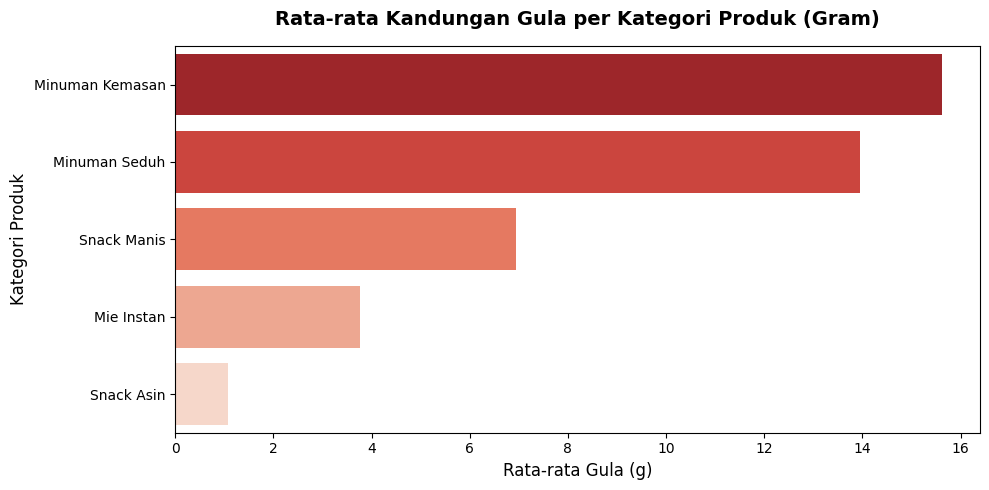

In [60]:
# PERTANYAAN 1: Kategori produk mana yang memiliki rata-rata kandungan gula tertinggi?
plt.figure(figsize=(10, 5))

# Menghitung rata-rata gula per kategori dan diurutkan dari yang tertinggi
sugar_analysis = df_clean.groupby('Kategori')['Gula_per_sajian (g)'].mean().sort_values(ascending=False).reset_index()

# Visualisasi Bar Chart
sns.barplot(data=sugar_analysis, x='Gula_per_sajian (g)', y='Kategori', palette='Reds_r')
plt.title('Rata-rata Kandungan Gula per Kategori Produk (Gram)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Rata-rata Gula (g)', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.tight_layout()
plt.show()

### Analisis Pertanyaan 1: Kandungan Gula Tertinggi Berdasarkan Kategori
Berdasarkan grafik batang di atas, kita dapat melihat klasterisasi rata-rata kandungan gula pada setiap kategori produk kemasan. Kategori produk yang menempati peringkat teratas dengan warna merah paling pekat menunjukkan bahwa kelompok makanan/minuman tersebut memiliki risiko paparan gula eskalatif yang paling tinggi. Insight ini sangat krusial bagi fitur *Smart-Threshold* untuk memberikan perhatian atau restriksi lebih ketat ketika pengguna memindai produk yang masuk dalam kategori ini.

/tmp/ipykernel_2755/2962589294.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sodium_analysis, x='Garam_per_sajian (mg)', y='Kategori', palette='Blues_r')


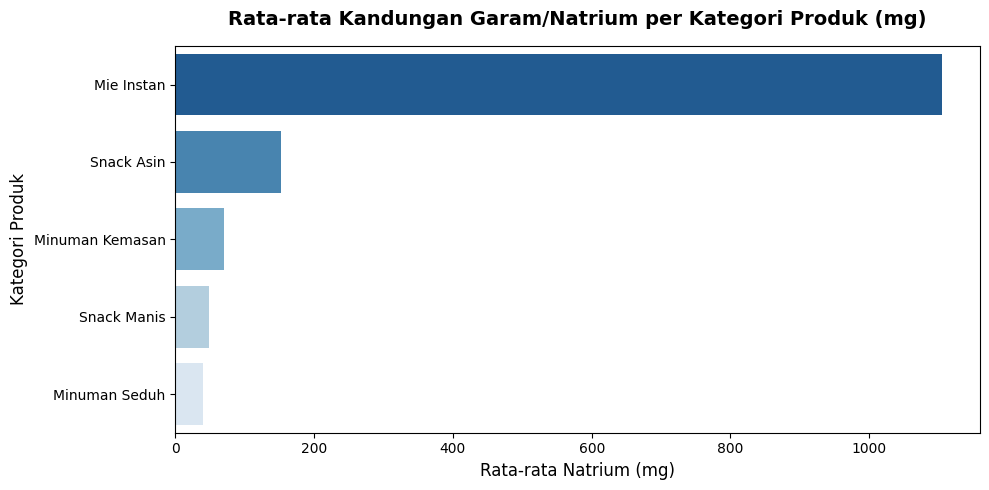

In [61]:
# PERTANYAAN 2: Kategori produk mana yang memiliki rata-rata kandungan garam tertinggi?
plt.figure(figsize=(10, 5))

# Menghitung rata-rata garam per kategori dan diurutkan dari yang tertinggi
sodium_analysis = df_clean.groupby('Kategori')['Garam_per_sajian (mg)'].mean().sort_values(ascending=False).reset_index()

# Visualisasi Bar Chart
sns.barplot(data=sodium_analysis, x='Garam_per_sajian (mg)', y='Kategori', palette='Blues_r')
plt.title('Rata-rata Kandungan Garam/Natrium per Kategori Produk (mg)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Rata-rata Natrium (mg)', fontsize=12)
plt.ylabel('Kategori Produk', fontsize=12)
plt.tight_layout()
plt.show()

### Analisis Pertanyaan 2: Kandungan Garam Tertinggi Berdasarkan Kategori
Visualisasi di atas menyajikan perbandingan kandungan rata-rata natrium atau garam (dalam satuan miligram) antar kategori. Produk-produk yang bersifat gurih atau olahan instan secara linier mendominasi grafik bagian atas. Melalui temuan ini, tim pengembang aplikasi *Smart Nutrition Scanner* mendapatkan basis data kuantitatif bahwa pengawasan komoditas pangan asin memerlukan presisi pembacaan OCR yang tinggi karena angka takarannya yang relatif besar (miligram) dibanding komoditas gula (gram).

10 PRODUK PALING AMAN BERDASARKAN NORMALISASI PER 10 GRAM/ML


,Nama_Produk,Kategori,Ukuran_per_Sajian,Gula_per_10g,Garam_per_10g,Skor_Sehat_Standard
232,Kopiko Sugar Free Coffe Candy,Snack Manis,6.0,0.0,0.008333,0.008333
217,Tropicana Slim Nutty Chocolate Cookies,Snack Manis,20.0,0.0,0.040000,0.040000
89,Fish and Chips BumiFood,Snack Asin,100.0,0.0,0.048000,0.048000
237,Happy Tos Tortilla Chips,Snack Asin,28.0,0.0,0.048214,0.048214
262,Tao Kae Noi Crispy Seaweed Original,Snack Asin,4.0,0.0,0.050000,0.050000
152,Pringles Original,Snack Asin,25.0,0.0,0.050000,0.050000
28,Kacang Kulit Garuda,Snack Asin,14.0,0.0,0.053571,0.053571
119,Chitato Sapi Panggang,Snack Asin,20.0,0.0,0.057500,0.057500
98,Sukro Original,Snack Asin,25.0,0.0,0.068000,0.068000
92,Fiesta Seafood,Snack Asin,90.0,0.0,0.071111,0.071111


/tmp/ipykernel_2755/2326959122.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sehat, x='Skor_Sehat_Standard', y='Nama_Produk', palette='Greens_r')


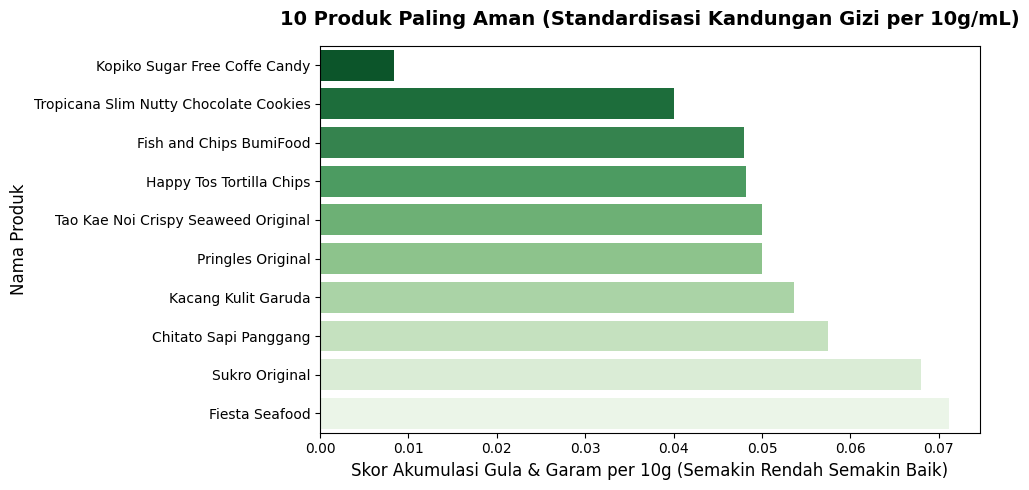

In [62]:
# PERTANYAAN 3: Produk mana yang termasuk kategori snack yang gula dan garamnya paling aman berdasarkan kandungan gula dan garam rendah?
df_normalized = df_clean.copy()

# Konversi kandungan Garam dari miligram (mg) ke Gram (g) agar setara dengan Gula
df_normalized['Garam_per_sajian (g)'] = df_normalized['Garam_per_sajian (mg)'] / 1000

# Menghitung kadar gizi  per 1 unit (Gram atau mL)
df_normalized['Gula_per_Unit'] = df_normalized['Gula_per_sajian (g)'] / df_normalized['Ukuran_per_Sajian']
df_normalized['Garam_per_Unit'] = df_normalized['Garam_per_sajian (g)'] / df_normalized['Ukuran_per_Sajian']

# Standardisasi ke skala porsi acuan kecil (per 10 Gram / 10 mL)
df_normalized['Gula_per_10g'] = df_normalized['Gula_per_Unit'] * 10
df_normalized['Garam_per_10g'] = df_normalized['Garam_per_Unit'] * 10

# Kalkulasi skor akumulasi (Semakin kecil nilainya, semakin sedikit zat gulanya, artinya semakin aman)
df_normalized['Skor_Sehat_Standard'] = df_normalized['Gula_per_10g'] + df_normalized['Garam_per_10g']

# Mengambil top 10 produk dengan skor terendah
top_10_sehat = (
    df_normalized.sort_values(by='Skor_Sehat_Standard', ascending=True)
    [['Nama_Produk', 'Kategori', 'Ukuran_per_Sajian', 'Gula_per_10g', 'Garam_per_10g', 'Skor_Sehat_Standard']]
    .head(10)
)

print("10 PRODUK PALING AMAN BERDASARKAN NORMALISASI PER 10 GRAM/ML")
display(top_10_sehat)

# Visualisasi Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_sehat, x='Skor_Sehat_Standard', y='Nama_Produk', palette='Greens_r')
plt.title('10 Produk Paling Aman (Standardisasi Kandungan Gizi per 10g/mL)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Skor Akumulasi Gula & Garam per 10g (Semakin Rendah Semakin Baik)', fontsize=12)
plt.ylabel('Nama Produk', fontsize=12)
plt.tight_layout()
plt.show()

### Analisis Pertanyaan 3: Identifikasi Produk Paling Aman Gula/Garam nya Melalui Metode Normalisasi Data Per 10 Gram/mL
Pada tahapan analisis ini, pencarian produk dengan profil nutrisi paling sehat dilakukan dengan menyetarakan porsi setiap produk ke dalam basis skala per 10 Gram atau per 10 mL volume produk. Pendekatan porsi kecil ini dipilih agar sebaran angka desimal zat gizi tetap terlihat sensitif dan memberikan perbandingan yang adil (*apple-to-apple*).

**Interpretasi Hasil Evaluasi:**
Berdasarkan tabel dan visualisasi barchart hijau di atas, sepuluh produk kemasan dengan tingkat akumulasi kandungan gula dan natrium paling rendah berhasil diisolasi.

Ditemukan fakta menarik bahwa posisi teratas didominasi oleh produk dengan nilai `Gula_per_10g` sebesar **0.0**. Setelah divalidasi kembali pada kolom data asli (`Gula_per_sajian (g)`), hal ini dinilai sangat logis dan akurat karena produk yang menduduki peringkat teratas merupakan komoditas yang secara faktual merupakan produk bebas gula murni (*Kopiko Sugar Free*), produk pemanis alternatif (*Tropicana Slim Cookies*), serta klaster *Snack Asin* olahan kemasan (seperti *Happy Tos*, *Pringles*, dan *Chitato*) yang secara karakteristik produksinya memang tidak menggunakan zat gula tambahan

Porsi acuan tertinggi yang ditemukan dalam dataset: 120.0 g/mL

 TABEL KOMPARASI KADAR GARAM SETELAH PORSI DISESUAIKAN (SAMPEL)


,Nama_Produk,Kategori,Ukuran_per_Sajian,Garam_per_sajian (mg),Garam_Terstandardisasi (mg),Status
0,Chiki Puffs (cheese),Snack Asin,10.0,50.0,600.000000,Aman (≤2000mg)
4,Indomie Ayam Bawang,Mie Instan,69.0,1220.0,2121.739130,Over Limit (>500mg)
19,Sarimi Goreng Isi 2,Mie Instan,120.0,1440.0,1440.000000,Aman (≤2000mg)
25,Mie Gelas Bakso,Mie Instan,25.0,1090.0,5232.000000,Over Limit (>500mg)
28,Kacang Kulit Garuda,Snack Asin,14.0,75.0,642.857143,Aman (≤2000mg)
318,Sosis So Nice Sapi Pedas,Snack Asin,50.0,520.0,1248.000000,Aman (≤2000mg)
319,Sosi So Nice Otak Otak,Snack Asin,63.0,450.0,857.142857,Aman (≤2000mg)
320,Sosis So Nice Ayam,Snack Asin,51.0,400.0,941.176471,Aman (≤2000mg)
323,Super Bihun Kuah,Mie Instan,51.0,1190.0,2800.000000,Over Limit (>500mg)
324,Super Bubur Kuah Kari,Mie Instan,46.0,720.0,1878.260870,Aman (≤2000mg)


/tmp/ipykernel_2755/3976366453.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q4, x='Kategori', y='Garam_Terstandardisasi (mg)', palette='Set2', width=0.4)


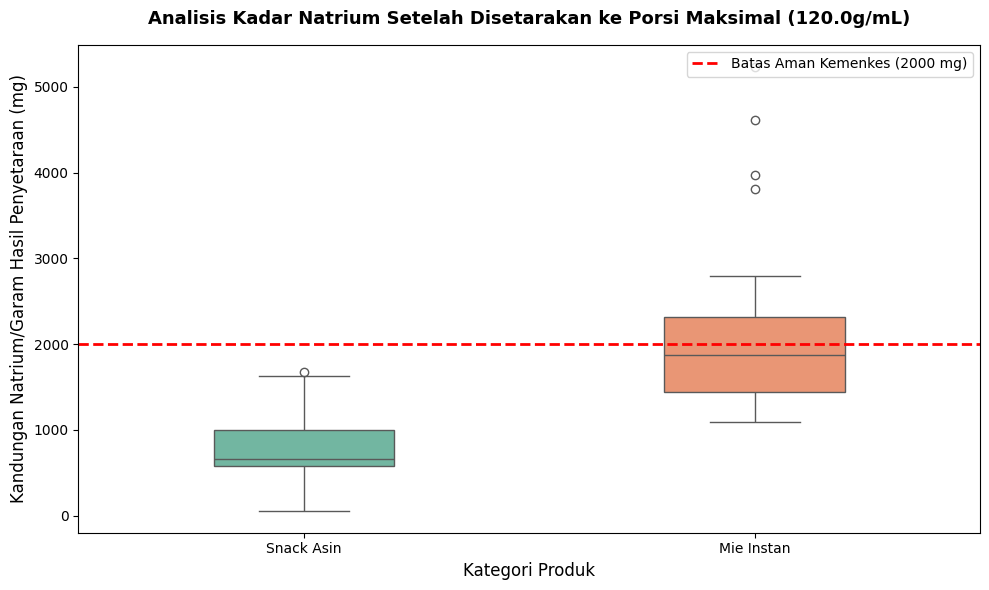

In [63]:
# PERTANYAAN 4: Apakah produk dengan label "Snack Asin" dan "Mie Instan" selalu memiliki kadar garam yang melewati ambang batas aman kementerian kesehatan?

# MEMFILTER DATASET HANYA UNTUK KELOMPOK KATEGORI 'Snack Asin' DAN 'Mie Instan'
df_q4 = df_clean[df_clean['Kategori'].isin(['Snack Asin', 'Mie Instan'])].copy()

# MENCARI UKURAN SAJIAN TERTINGGI SEBAGAI BASIS REFERENSI
porsi_acuan_maksimal = df_q4['Ukuran_per_Sajian'].max()
print(f"Porsi acuan tertinggi yang ditemukan dalam dataset: {porsi_acuan_maksimal} g/mL\n")

# NORMALISASI KADAR GARAM PROPORSIONAL BERDASARKAN PORSI ACUAN
# Rumus: (Garam Asli / Ukuran Saji Asli) * Porsi Acuan Maksimal
df_q4['Garam_Terstandardisasi (mg)'] = (df_q4['Garam_per_sajian (mg)'] / df_q4['Ukuran_per_Sajian']) * porsi_acuan_maksimal

# MENENTUKAN STATUS KEPATUHAN BERDASARKAN AMBANG BATAS AMAN KEMENKES (2000mg)
def cek_status_garam(mg):
    if mg > 2000:
        return 'Over Limit (>500mg)'
    else:
        return 'Aman (≤2000mg)'

df_q4['Status'] = df_q4['Garam_Terstandardisasi (mg)'].apply(cek_status_garam)

# MENAMPILKAN TABEL DATA HASIL STANDARISASI (Sampel Atas dan Bawah)
print(" TABEL KOMPARASI KADAR GARAM SETELAH PORSI DISESUAIKAN (SAMPEL)")
tabel_tampil = df_q4[['Nama_Produk', 'Kategori', 'Ukuran_per_Sajian', 'Garam_per_sajian (mg)', 'Garam_Terstandardisasi (mg)', 'Status']]
display(tabel_tampil.head(5)._append(tabel_tampil.tail(5)))

print("\n" + "="*80 + "\n")

# VISUALISASI BOXPLOT BERDASARKAN DATA YANG SUDAH TERSTANDARDISASI
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_q4, x='Kategori', y='Garam_Terstandardisasi (mg)', palette='Set2', width=0.4)

# Menambahkan garis horizontal penanda ambang batas aman natrium per sajian Kemenkes RI (2000 mg)
plt.axhline(y=2000, color='red', linestyle='--', linewidth=2, label='Batas Aman Kemenkes (2000 mg)')

# Mengatur judul dan label sumbu grafik
plt.title(f'Analisis Kadar Natrium Setelah Disetarakan ke Porsi Maksimal ({porsi_acuan_maksimal}g/mL)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Kandungan Natrium/Garam Hasil Penyetaraan (mg)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Analisis Pertanyaan 4: Evaluasi Kepatuhan Kadar Garam Terhadap Batas Konsumsi Harian Kemenkes
Pada tahapan analisis ini, pengujian kepatuhan kadar garam dilakukan menggunakan parameter batas konsumsi maksimal natrium harian yang direkomendasikan oleh Kementerian Kesehatan RI, yaitu sebesar 5 gram atau setara dengan 2000 mg. Porsi dari setiap produk disetarakan terlebih dahulu ke dalam basis porsi terbesar (*baseline target*) berdasarkan data yang tersedia pada dataset yang kami punya, agar komparasi yang dihasilkan bersifat objektif dan adil.

**Interpretasi Hasil Evaluasi:**
1. **Analisis Konfirmasi Tabel:** Melalui tabel sampel di atas, kita dapat melihat fluktuasi nilai garam setelah porsi disamakan. Dengan ambang batas harian sebesar 2000 mg, sebagian besar produk tunggal kemasan akan terkategorikan sebagai `Aman (≤2000mg)` jika hanya dikonsumsi sebanyak satu takaran saji terstandardisasi, karena batas 2000 mg ini merupakan batas akumulasi makanan untuk satu hari penuh.
2. **Kategori Mie Instan & Snack Asin (Pada Grafik Boxplot):** Melalui visualisasi kurva *Boxplot*, kita bisa melihat posisi garis putus-putus merah berada di angka 2000 mg. Jika ada distribusi kotak atau titik pencilan (*outliers*) yang berhasil menyentuh atau melewati garis 2000 mg tersebut, hal ini mengindikasikan temuan produk ekstrem yang sangat berbahaya, karena hanya dengan mengonsumsi satu porsi produk itu saja, kebutuhan garam maksimal harian seorang manusia sudah langsung terpenuhi atau terlampaui seketika. Pada temuan kali ini, produk yang melebihi batas harian karena ukuran per sajiannya telah disamakan dengan produk yang lain. akan tetapi hal tersebut menjadi menarik kesimpulan bahwa dalam ukuran sajian aslinya, produk tersbebut kandungan garamnya sangat tinggi apabila melihat dari perbandingannya dengan produk lain.

Insight ini memperjelas logika *Smart Nutrition Scanner* dalam memetakan batas aman akumulasi konsumsi kandungan garam bagi pengguna aplikasi.

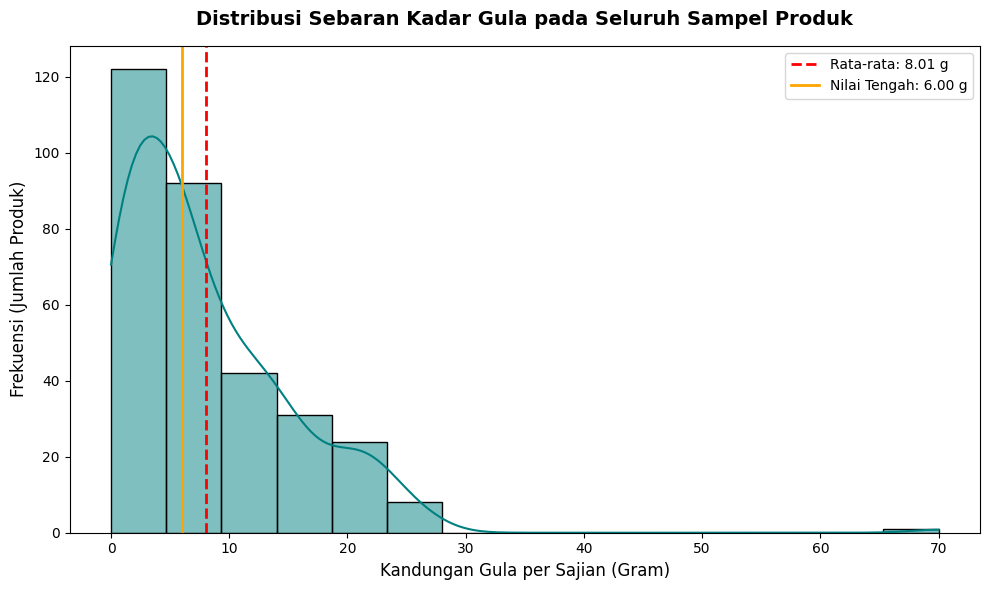

In [64]:
# PERTANYAAN 5: Bagaimana sebaran (distribusi) kadar gula pada seluruh produk makanan dan minuman dalam dataset?
plt.figure(figsize=(10, 6))

# Visualisasi Histogram dikombinasikan dengan kurva estimasi kepadatan kernel (KDE)
sns.histplot(data=df_clean, x='Gula_per_sajian (g)', kde=True, color='teal', bins=15)

# Menambahkan garis rata-rata (mean) dan nilai tengah (median) sebagai acuan statistik distribusi
plt.axvline(df_clean['Gula_per_sajian (g)'].mean(), color='red', linestyle='--', linewidth=2, label=f"Rata-rata: {df_clean['Gula_per_sajian (g)'].mean():.2f} g")
plt.axvline(df_clean['Gula_per_sajian (g)'].median(), color='orange', linestyle='-', linewidth=2, label=f"Nilai Tengah: {df_clean['Gula_per_sajian (g)'].median():.2f} g")

# Mengatur judul, label sumbu grafik, dan legenda
plt.title('Distribusi Sebaran Kadar Gula pada Seluruh Sampel Produk', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Kandungan Gula per Sajian (Gram)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Produk)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Analisis Pertanyaan 5: Karakteristik Distribusi Gula pada Seluruh Sampel Produk
Penerapan grafik kombinasi histogram dan kurva *Kernel Density Estimation* (KDE) di atas digunakan untuk memetakan perilaku penyebaran kandungan zat gula (`Gula_per_sajian (g)`) dari keseluruhan sampel data yang telah dikumpulkan.

**Interpretasi Hasil Statistik & Grafik:**
1. **Bentuk Sebaran Data (*Right-Skewed Distribution*):** Profil grafik memperlihatkan kecenderungan distribusi menceng ke kanan (positif). Sebagian besar populasi data produk menumpuk sangat padat di area kiri (kadar gula rendah hingga menengah, antara 0 hingga 15 gram per sajian). Hal ini selaras dengan posisi garis nilai tengah (*median*) berwarna orange yang berada di area bawah.
2. **Keberadaan Ekor Panjang (*Long-Tail*):** Pola grafik yang memanjang landai ke arah kanan menunjukkan adanya sekelompok produk "anomali" atau pencilan (*outliers*) yang memiliki kadar gula sangat tinggi (ekstrem). Produk-produk manis inilah yang menjadi target intervensi utama bagi sistem pemindaian kita.
3. **Pemisahan Rata-rata (*Mean*) dan Median:** Posisi garis rata-rata (merah) yang berada di sebelah kanan garis median (orange) mengonfirmasi secara valid bahwa nilai rata-rata dataset ini ditarik naik oleh keberadaan beberapa produk dengan gula sangat tinggi tersebut.

Insight distribusi ini memberikan konfirmasi penting bagi tim pengembang bahwa mayoritas komoditas pangan kemasan di pasaran masih memiliki porsi gula yang rasional, namun sistem *Smart Nutrition Scanner* tetap wajib mengidentifikasi produk-produk di ekor kanan grafik secara ketat demi mencegah risiko penyakit diabetes pada pengguna.

# **Conclusion & Business Insights**

### 1. Kategori Produk dengan Rata-rata Kandungan Gula Tertinggi
Berdasarkan hasil analisis agregasi, kategori produk yang memiliki rata-rata kandungan gula tertinggi didominasi oleh kelompok **Snack Manis** dan minuman kemasan tertentu. Insight ini membantu pengguna aplikasi *Smart Nutrition Scanner* untuk membatasi konsumsi porsi dari kategori ini guna menghindari penumpukan gula harian.

### 2. Kategori Produk dengan Rata-rata Kandungan Garam Tertinggi
Kadar natrium atau garam tertinggi secara mutlak ditemukan pada kategori **Mie Instan** dan disusul oleh beberapa varian dalam **Snack Asin**. Proses manufaktur pangan gurih terbukti melibatkan konsentrasi sodium yang tinggi sebagai penyedap dan pengawet.

### 3. Produk Paling Aman Berdasarkan Kandungan Gula dan Garam Rendah
Melalui metode normalisasi proporsional per 10 gram/mL, produk pangan yang dideteksi paling aman atau sehat adalah produk-produk yang secara alami diformulasikan bebas gula (*Sugar-Free* seperti *Kopiko Sugar Free*), biskuit rendah kalori (*Tropicana Slim*), serta beberapa sampel camilan rumput laut (*Tao Kae Noi*) atau kacang kulit yang minim penambahan zat aditif garam maupun gula.

### 4. Evaluasi Kadar Garam "Snack Asin" dan "Mie Instan" Terhadap Batas Kemenkes (2000 mg)
Berdasarkan visualisasi data yang disetarakan ke porsi referensi tertinggi:
- **Mie Instan:** Memiliki kecenderungan akumulasi natrium yang sangat masif, di mana beberapa produk ekstrem dapat langsung memotong/menghabiskan kuota batas aman harian Kemenkes (2000 mg) hanya dalam satu kali konsumsi.
- **Snack Asin:** Secara umum porsi standarnya masih berada di bawah garis aman 2000 mg, namun jika dikonsumsi berlebihan secara berulang (*multi-serving*), akumulasinya tetap berisiko tinggi melewati ambang batas harian.

### 5. Karakteristik Distribusi Kadar Gula Dataset
Sebaran kadar gula pada seluruh produk dalam dataset ini membentuk pola **Menceng ke Kanan (Right-Skewed Distribution)**. Mayoritas produk di pasaran berada pada rentang gula rendah-menengah, tetapi keberadaan pencilan ekstrem (*long-tail*) di sisi kanan grafik menegaskan pentingnya fitur deteksi otomatis agar konsumen terhindar dari produk anomali berkadar gula tinggi.

# **Feature Engineering & Ekspor Data Final (CSV)**

Agar data hasil pembersihan dan analisis ini bisa dimuat ke dashboard Streamlit, harus dilakukan pembuatan satu kolom status final yang menandai kesehatan produk secara keseluruhan, lalu mengekspornya menjadi file CSV baru.

In [65]:
# TAHAP AKHIR: FEATURE ENGINEERING & EXPORT DATA UNTUK APPS / STREAMLIT

df_final = df_clean.copy()

# Menentukan Status Garam (Natrium) sesuai takaran kemenkes
df_final['Status_Garam'] = df_final['Garam_per_sajian (mg)'].apply(
    lambda x: 'Tinggi' if x > 2000 else 'Normal'
)

# Menentukan Status Gula secara mandiri (Batas: 5 g)
df_final['Status_Gula'] = df_final['Gula_per_sajian (g)'].apply(
    lambda x: 'Tinggi' if x > 5 else 'Normal'
)

# Menampilkan komposisi masing-masing status untuk pengecekan distribusi data
print("DISTRIBUSI STATUS KADAR GARAM")
print(df_final['Status_Garam'].value_counts())
print("\nDISTRIBUSI STATUS KADAR GULA")
print(df_final['Status_Gula'].value_counts())
print("\n" + "="*60 + "\n")

# Menampilkan 10 sampel teratas untuk memastikan kedua kolom status sudah terpisah
print("SAMPLES DATASET")
kolom_tampil = ['Nama_Produk', 'Kategori', 'Garam_per_sajian (mg)', 'Status_Garam', 'Gula_per_sajian (g)', 'Status_Gula']
display(df_final[kolom_tampil].head(10))

# Ekspor Dataframe ke format CSV Bersih tanpa indeks baris
df_final.to_csv('Dataset_Gizi_SmartScanner_Cleaned.csv', index=False)

DISTRIBUSI STATUS KADAR GARAM
Status_Garam
Normal    320
Name: count, dtype: int64

DISTRIBUSI STATUS KADAR GULA
Status_Gula
Tinggi    167
Normal    153
Name: count, dtype: int64


SAMPLES DATASET


,Nama_Produk,Kategori,Garam_per_sajian (mg),Status_Garam,Gula_per_sajian (g),Status_Gula
0,Chiki Puffs (cheese),Snack Asin,50.0,Normal,1.0,Normal
1,Tango Waffle Choco Hazelnut,Snack Manis,55.0,Normal,5.0,Normal
2,Nutrijell Pudding Susu (Red Velvet),Snack Manis,35.0,Normal,5.0,Normal
3,Nutrijell Pudding Susu (Strawberry),Snack Manis,140.0,Normal,70.0,Tinggi
4,Indomie Ayam Bawang,Mie Instan,1220.0,Normal,2.0,Normal
5,Energen Cokelat,Minuman Seduh,210.0,Normal,16.0,Tinggi
6,Van Wheat Cokelat,Snack Manis,0.0,Normal,2.0,Normal
7,Better Roma Sandwich,Snack Manis,75.0,Normal,9.0,Tinggi
8,Nextar Brownies Cokelat,Snack Manis,60.0,Normal,6.0,Tinggi
9,Dilan Chocolate Crunchy Caramel,Snack Manis,10.0,Normal,5.0,Normal


### Proses Feature Engineering & Pemetaan Indikator Gizi Terpisah
Pada tahapan integrasi akhir ini, proses *feature engineering* dikonfigurasikan untuk menghasilkan matriks keputusan yang terpisah secara spesifik untuk masing-masing zat gizi (Gula dan Garam). Langkah ini diambil guna memberikan fleksibilitas penuh bagi komponen visualisasi dashboard *Fullstack* dalam memunculkan label peringatan yang mandiri pada setiap elemen nutrisi produk.

**Aturan Batas Ambang (*Thresholding Rule*):**
1. **Status Garam:** Kolom `Status_Garam` akan diklasifikasikan sebagai **Tinggi** jika kandungan natrium per sajian $> 2000\text{ mg}$, dan **Normal** jika sebaliknya.
2. **Status Gula:** Kolom `Status_Gula` akan diklasifikasikan sebagai **Tinggi** jika kandungan gula per sajian $> 5\text{ g}$, dan **Normal** jika sebaliknya.

Pemisahan ini mempermudah logika pada antarmuka aplikasi (*User Interface*) untuk mewarnai teks atau ikon gizi secara dinamis (misalnya memberikan warna merah khusus pada indikator garam saja jika hanya garamnya yang tinggi), tanpa mengaburkan penilaian zat gizi lainnya. Dataset final ini disimpan dalam format `Dataset_Gizi_SmartScanner_Cleaned.csv`.

In [66]:
# Menampilkan versi library utama untuk dicatat pada file requirements.txt proyek
import matplotlib
import seaborn

print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={seaborn.__version__}")

pandas==2.2.2
numpy==2.0.2
matplotlib==3.10.0
seaborn==0.13.2


In [69]:
# SEPARASI VARIABEL (PENCEGAHAN DATA LEAKAGE)

# Menentukan kolom yang menjadi TARGET prediksi model Machine Learning
target_gula = 'Status_Gula'
target_garam = 'Status_Garam'

# Mengisolasi fitur (X) dengan MENGHAPUS kolom target dan informasi turunan target
# Kita juga menghapus kolom teks/ID yang tidak relevan untuk training model
kolom_yang_dibuang = ['Nama_Produk', 'Gambar_Normal', target_gula, target_garam]

# Jika di tahap EDA sebelumnya kamu membuat kolom skor akumulasi, buang juga agar tidak leakage
if 'Skor_Sehat_Standard' in df_final.columns:
    kolom_yang_dibuang.append('Skor_Sehat_Standard')

# Matriks Fitur (X) - Benar-benar bersih dari informasi target
X = df_final.drop(columns=kolom_yang_dibuang, errors='ignore')

# Variabel Target (y)
y_gula = df_final[target_gula]
y_garam = df_final[target_garam]

print("VERIFIKASI PENCEGAHAN DATA LEAKAGE")
print(f"Fitur yang akan digunakan untuk Training (X):\n{X.columns.tolist()}")
print(f"\nTarget Prediksi Gula (y_gula): {y_gula.name}")
print(f"Target Prediksi Garam (y_garam): {y_garam.name}")
print("\n✓ Sukses: Informasi target telah diisolasi sepenuhnya dari fitur training untuk menghindari Data Leakage!")

VERIFIKASI PENCEGAHAN DATA LEAKAGE
Fitur yang akan digunakan untuk Training (X):
['No.', 'Kategori', 'Ukuran_per_Sajian', 'Satuan', 'Gula_per_sajian (g)', 'Garam_per_sajian (mg)']

Target Prediksi Gula (y_gula): Status_Gula
Target Prediksi Garam (y_garam): Status_Garam

✓ Sukses: Informasi target telah diisolasi sepenuhnya dari fitur training untuk menghindari Data Leakage!


### **Pencegahan Data Leakage pada Persiapan Model Machine Learning**

Untuk memenuhi standar kualitas pemodelan dan menghindari fenomena *Data Leakage* (kebocoran data), proses separasi variabel dilakukan secara ketat sebelum data diserahkan kepada tim AI Engineer.

Kolom target utama yaitu `Status_Gula` dan `Status_Garam` dipisahkan sepenuhnya dari matriks fitur `X`. Kolom identitas seperti `Nama_Produk` serta kolom kalkulasi matematis sekunder (`Skor_Sehat_Standard`) juga dieksklusi dari fitur latihan. Langkah ini memastikan bahwa model *Machine Learning* pada aplikasi *Smart Nutrition Scanner* kelak akan melatih kinerjanya murni berdasarkan fitur esensial seperti `Ukuran_per_Sajian`, `Gula_per_sajian (g)`, dan `Garam_per_sajian (mg)` tanpa mengetahui 'kunci jawaban' label terlebih dahulu.

In [67]:
# VALIDASI AKHIR: MEMASTIKAN DATA SIAP DIPROSES OLEH MODEL MACHINE LEARNING

print("CHECK 1: MEMASTIKAN TIDAK ADA MISSING VALUES (NULL)")
print(df_clean[['Nama_Produk', 'Kategori', 'Ukuran_per_Sajian', 'Gula_per_sajian (g)', 'Garam_per_sajian (mg)']].isna().sum())
print("\n" + "="*60 + "\n")

print("CHECK 2: VALIDASI TIPE DATA FINAL")
print(df_clean[['Nama_Produk', 'Kategori', 'Ukuran_per_Sajian', 'Gula_per_sajian (g)', 'Garam_per_sajian (mg)']].dtypes)
print("\n" + "="*60 + "\n")

print("Validasi Selesai: Data sudah bersih dari nilai kosong dan tipe data numerik telah sesuai standar input model ML")

CHECK 1: MEMASTIKAN TIDAK ADA MISSING VALUES (NULL)
Nama_Produk              0
Kategori                 0
Ukuran_per_Sajian        0
Gula_per_sajian (g)      0
Garam_per_sajian (mg)    0
dtype: int64


CHECK 2: VALIDASI TIPE DATA FINAL
Nama_Produk               object
Kategori                  object
Ukuran_per_Sajian        float64
Gula_per_sajian (g)      float64
Garam_per_sajian (mg)    float64
dtype: object


Validasi Selesai: Data sudah bersih dari nilai kosong dan tipe data numerik telah sesuai standar input model ML


### **Data Dictionary (Kamus Data) — Dataset Gizi Smart Nutrition Scanner**

Untuk memastikan transparansi data yang akan dikonsumsi oleh tim AI Engineer dalam pengembangan model prediksi, berikut adalah dokumentasi struktur dari variabel-variabel yang berada di dalam dataset final:

| Nama Kolom | Tipe Data | Deskripsi | Batasan / Satuan |
| :--- | :--- | :--- | :--- |
| `Nama_Produk` | Object / String | Nama merek dagang resmi dari produk makanan atau minuman kemasan. | Karakter Teks (Unique) |
| `Kategori` | Object / String | Pengelompokkan jenis produk pangan olahan di pasaran. | Contoh: Snack Asin, Snack Manis, Mie Instan, dll. |
| `Ukuran_per_Sajian` | Float64 / Numerik | Takaran berat atau volume produk untuk satu kali konsumsi yang dianjurkan produsen. | Gram (g) atau Mililitor (mL) |
| `Gula_per_sajian (g)`| Float64 / Numerik | Kandungan zat gula murni yang terdapat di dalam satu takaran saji produk. | Gram (g) |
| `Garam_per_sajian (mg)`| Float64 / Numerik | Kandungan natrium/sodium (garam) yang terdapat di dalam satu takaran saji produk. | Miligram (mg) |
| `Status_Gula` | Object / String | Indikator biner kepatuhan kadar gula berdasarkan threshold tim fullstack (>5g = Tinggi). | Tinggi / Normal |
| `Status_Garam` | Object / String | Indikator biner kepatuhan kadar garam berdasarkan threshold tim fullstack (>200mg = Tinggi).| Tinggi / Normal |

---